In [1]:
!pip install gdown


In [2]:
import gdown

gdrive_folder_id = '1dZvL1gi5QLwOGrfdn9XEsi4EnXx535bD'
output_directory = './datasets'
gdown.download_folder(url=f'https://drive.google.com/drive/folders/{gdrive_folder_id}', output=output_directory, quiet=False, use_cookies=False)



Retrieving folder contents


Processing file 1JHblwM88w4g70lZwiLDf6qPz8t0wZnd6 input_test.csv
Processing file 1jQ16W4DJG1ZfJ_R7V_9cQIALwN3lruE5 input.csv
Processing file 1cGDczlanBC59TbpNIe8_s0-yUtIrmnwm labels_test.csv
Processing file 1Zy3y6wBLZTI67BZhXzwQtgWJ8m50Oggl labels.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1JHblwM88w4g70lZwiLDf6qPz8t0wZnd6
From (redirected): https://drive.google.com/uc?id=1JHblwM88w4g70lZwiLDf6qPz8t0wZnd6&confirm=t&uuid=b8a06e87-8085-41a9-83b2-fb0746f90211
To: /content/datasets/input_test.csv
100%|██████████| 300M/300M [00:05<00:00, 51.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1jQ16W4DJG1ZfJ_R7V_9cQIALwN3lruE5
From (redirected): https://drive.google.com/uc?id=1jQ16W4DJG1ZfJ_R7V_9cQIALwN3lruE5&confirm=t&uuid=f75a4ee2-9495-46c7-89bc-b3d7bfe07c9e
To: /content/datasets/input.csv
100%|██████████| 1.50G/1.50G [00:26<00:00, 56.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1cGDczlanBC59TbpNIe8_s0-yUtIrmnwm
To: /content/datasets/labels_test.csv
100%|██████████| 800/800 [00:00<00:00, 1.19MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Zy3y6wBLZTI67BZhXzwQtgWJ8m50Og

['./datasets/input_test.csv',
 './datasets/input.csv',
 './datasets/labels_test.csv',
 './datasets/labels.csv']

In [3]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
import matplotlib.pyplot as plt
import random

LOAD DATASET


In [4]:
X_train = np.loadtxt('./datasets/input.csv', delimiter=',')
Y_train = np.loadtxt('./datasets/labels.csv', delimiter=',')

X_test = np.loadtxt('./datasets/input_test.csv', delimiter=',')
Y_test = np.loadtxt('./datasets/labels_test.csv', delimiter=',')


In [5]:
X_train = X_train.reshape(len(X_train), 100, 100, 3)
Y_train = Y_train.reshape(len(Y_train), 1)

X_test = X_test.reshape(len(X_test), 100, 100, 3)
Y_test = Y_test.reshape(len(Y_test), 1)
X_train/=255.0
X_test




array([[[[118.,  82.,  96.],
         [109.,  71.,  82.],
         [116.,  77.,  78.],
         ...,
         [170., 134., 100.],
         [165., 129.,  93.],
         [163., 127.,  91.]],

        [[ 95.,  62.,  73.],
         [104.,  69.,  76.],
         [110.,  75.,  73.],
         ...,
         [174., 138., 102.],
         [170., 134.,  98.],
         [167., 132.,  94.]],

        [[177., 148., 153.],
         [181., 151., 153.],
         [173., 142., 137.],
         ...,
         [175., 141., 103.],
         [171., 137.,  99.],
         [168., 135.,  94.]],

        ...,

        [[ 63.,  60.,  77.],
         [ 65.,  64.,  80.],
         [ 65.,  67.,  82.],
         ...,
         [148.,  98.,  63.],
         [155.,  98.,  43.],
         [145.,  84.,  19.]],

        [[ 58.,  55.,  72.],
         [ 60.,  59.,  75.],
         [ 60.,  62.,  77.],
         ...,
         [132.,  82.,  49.],
         [143.,  86.,  31.],
         [138.,  77.,  14.]],

        [[ 58.,  55.,  72.],
       

In [6]:
print("Shape of X_train:" , X_train.shape)
print("Shape of Y_train:" , Y_train.shape)
print("Shape of X_test:" , X_test.shape)
print("Shape of Y_test:" , Y_test.shape)


Shape of X_train: (2000, 100, 100, 3)
Shape of Y_train: (2000, 1)
Shape of X_test: (400, 100, 100, 3)
Shape of Y_test: (400, 1)


In [7]:
X_train[1,:
        ]

array([[[0.51372549, 0.50196078, 0.52941176],
        [0.62745098, 0.61568627, 0.64313725],
        [0.77647059, 0.75294118, 0.8       ],
        ...,
        [0.98039216, 0.97647059, 0.96862745],
        [1.        , 1.        , 0.99215686],
        [0.98039216, 0.97647059, 0.96078431]],

       [[0.54901961, 0.5372549 , 0.56470588],
        [0.49803922, 0.48627451, 0.51372549],
        [0.47058824, 0.44705882, 0.48627451],
        ...,
        [0.98431373, 0.99215686, 0.98823529],
        [0.99607843, 1.        , 0.99215686],
        [0.99607843, 1.        , 0.98431373]],

       [[0.8       , 0.79215686, 0.81176471],
        [0.73333333, 0.7254902 , 0.74509804],
        [0.57647059, 0.55686275, 0.58039216],
        ...,
        [0.97647059, 1.        , 1.        ],
        [0.93333333, 0.96862745, 0.94901961],
        [0.90980392, 0.94509804, 0.9254902 ]],

       ...,

       [[0.68235294, 0.71372549, 0.76470588],
        [0.6745098 , 0.70588235, 0.75686275],
        [0.69803922, 0

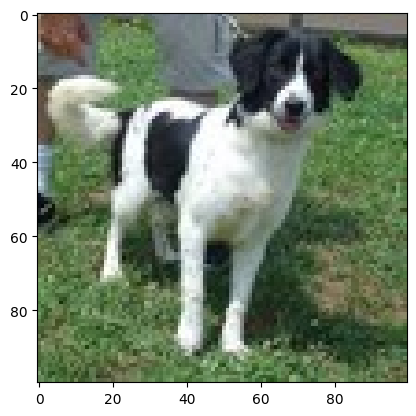

In [8]:
idx = random.randint(0,len(X_train))
plt.imshow(X_train[idx,:])
plt.show()

# New Section

**MODEL**

In [9]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)),
    MaxPooling2D((2,2)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# opt = keras.optimizers.SGD(learning_rate=0.001)
model.compile(loss='binary_crossentropy', optimizer = 'adam', metrics=['accuracy'])

In [ ]:
model.fit(X_train, Y_train, epochs=5, batch_size=64)

Epoch 1/5
14/32 ━━━━━━━━━━━━━━━━━━━━ 15s 863ms/step - accuracy: 0.5252 - loss: 0.7680

In [ ]:
model.evaluate(X_test, Y_test)

# PREDICTION


In [ ]:
idx2 = random.randint(0,len(Y_test))
plt.imshow(X_test[idx2,:])
plt.show()

y_pred = model.predict(X_test[idx2,:].reshape(1,100,100,3))
y_pred = y_pred>0.5

if(y_pred == 0):
  pred='dog'
else:
  pred='cat'

print("simon says:",pred)